# Compare Chained And Direct Estimates

This notebook checks whether chaining `Y -> E` and `E -> U` produces an implied `Y -> U` relationship close to the direct `Y -> U` estimate.

We compare:
- static OLS break-even GDP growth
- time-varying statsmodels local-level break-even GDP growth

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / 'data' / 'prepared' / 'analysis_dataset_quarterly.csv'
OUTPUT_PATH = PROJECT_ROOT / 'outputs' / 'compare_chained_and_direct.csv'

## Load Dataset

In [2]:
analysis_df = pd.read_csv(DATA_PATH, parse_dates=['date']).sort_values('date').reset_index(drop=True)
analysis_df['Y_lag1'] = analysis_df['Y'].shift(1)
analysis_df['Y_lag2'] = analysis_df['Y'].shift(2)
analysis_df['E_lag1'] = analysis_df['E'].shift(1)
analysis_df['E_lag2'] = analysis_df['E'].shift(2)
analysis_df['d2020q2'] = (analysis_df['date'] == pd.Timestamp('2020-04-01')).astype(float)
analysis_df['d2020q3'] = (analysis_df['date'] == pd.Timestamp('2020-07-01')).astype(float)
df = analysis_df.dropna().reset_index(drop=True)
df.head()

,date,E,U,Y,Y_lag1,Y_lag2,E_lag1,E_lag2,d2020q2,d2020q3
0,1992-07-01,-1.132308,0.459021,-0.726074,-0.085709,0.570575,-0.146517,-0.297662,0.0,0.0
1,1992-10-01,-0.847614,0.586024,-0.501668,-0.726074,-0.085709,-1.132308,-0.146517,0.0,0.0
2,1993-01-01,-0.839623,0.505504,-0.332376,-0.501668,-0.726074,-0.847614,-1.132308,0.0,0.0
3,1993-04-01,0.812695,0.544153,0.917484,-0.332376,-0.501668,-0.839623,-0.847614,0.0,0.0
4,1993-07-01,-0.310166,0.405117,0.381316,0.917484,-0.332376,0.812695,-0.839623,0.0,0.0


## Static OLS Comparison

In [3]:
# Direct Y -> U
X_direct = sm.add_constant(df[['Y', 'Y_lag1', 'Y_lag2', 'd2020q2', 'd2020q3']])
ols_direct = sm.OLS(df['U'], X_direct).fit()
alpha_direct = float(ols_direct.params['const'])
beta_direct = float(ols_direct.params['Y'] + ols_direct.params['Y_lag1'] + ols_direct.params['Y_lag2'])
be_direct_qoq = -alpha_direct / beta_direct

# Y -> E
X_e = sm.add_constant(df[['Y', 'Y_lag1', 'Y_lag2', 'd2020q2', 'd2020q3']])
ols_e = sm.OLS(df['E'], X_e).fit()
alpha_e = float(ols_e.params['const'])
beta_e = float(ols_e.params['Y'] + ols_e.params['Y_lag1'] + ols_e.params['Y_lag2'])

# E -> U
X_u_on_e = sm.add_constant(df[['E', 'E_lag1', 'E_lag2', 'd2020q2', 'd2020q3']])
ols_u_on_e = sm.OLS(df['U'], X_u_on_e).fit()
alpha_u_on_e = float(ols_u_on_e.params['const'])
theta_u_on_e = float(ols_u_on_e.params['E'] + ols_u_on_e.params['E_lag1'] + ols_u_on_e.params['E_lag2'])

alpha_chain = alpha_u_on_e + theta_u_on_e * alpha_e
beta_chain = theta_u_on_e * beta_e
be_chain_qoq = -alpha_chain / beta_chain

def ann(x):
    return ((1 + x / 100) ** 4 - 1) * 100

static_compare = pd.DataFrame({
    'measure': ['alpha', 'sum_beta', 'break_even_qoq', 'break_even_annualized'],
    'direct_Y_to_U': [alpha_direct, beta_direct, be_direct_qoq, ann(be_direct_qoq)],
    'chained_Y_to_E_to_U': [alpha_chain, beta_chain, be_chain_qoq, ann(be_chain_qoq)],
})
static_compare

,measure,direct_Y_to_U,chained_Y_to_E_to_U
0,alpha,0.125988,0.068731
1,sum_beta,-0.271936,-0.153018
2,break_even_qoq,0.463299,0.449172
3,break_even_annualized,1.866113,1.808830


## Time-Varying Statsmodels Comparison

In [4]:
def fit_local_level(endog, exog, fixed_sigma2_level, start_map):
    model = sm.tsa.UnobservedComponents(endog, level='local level', exog=exog)
    start_params = model.start_params.copy()
    name_to_idx = {name: idx for idx, name in enumerate(model.param_names)}
    for name, value in start_map.items():
        if name in name_to_idx:
            start_params[name_to_idx[name]] = value
    with model.fix_params({'sigma2.level': fixed_sigma2_level}):
        result = model.fit(start_params=start_params, disp=False, includes_fixed=True)
    return model, result

sigma_direct = float(ols_direct.resid.std(ddof=int(ols_direct.df_model) + 1))
sigma_e = float(ols_e.resid.std(ddof=int(ols_e.df_model) + 1))
sigma_u_on_e = float(ols_u_on_e.resid.std(ddof=int(ols_u_on_e.df_model) + 1))

_, res_direct = fit_local_level(
    df['U'],
    df[['Y', 'Y_lag1', 'Y_lag2', 'd2020q2', 'd2020q3']],
    (0.05 * sigma_direct) ** 2,
    {
        'sigma2.level': (0.05 * sigma_direct) ** 2,
        'beta.Y': float(ols_direct.params['Y']),
        'beta.Y_lag1': float(ols_direct.params['Y_lag1']),
        'beta.Y_lag2': float(ols_direct.params['Y_lag2']),
        'beta.d2020q2': float(ols_direct.params['d2020q2']),
        'beta.d2020q3': float(ols_direct.params['d2020q3']),
    },
)

_, res_e = fit_local_level(
    df['E'],
    df[['Y', 'Y_lag1', 'Y_lag2', 'd2020q2', 'd2020q3']],
    (0.05 * sigma_e) ** 2,
    {
        'sigma2.level': (0.05 * sigma_e) ** 2,
        'beta.Y': float(ols_e.params['Y']),
        'beta.Y_lag1': float(ols_e.params['Y_lag1']),
        'beta.Y_lag2': float(ols_e.params['Y_lag2']),
        'beta.d2020q2': float(ols_e.params['d2020q2']),
        'beta.d2020q3': float(ols_e.params['d2020q3']),
    },
)

_, res_u_on_e = fit_local_level(
    df['U'],
    df[['E', 'E_lag1', 'E_lag2', 'd2020q2', 'd2020q3']],
    (0.05 * sigma_u_on_e) ** 2,
    {
        'sigma2.level': (0.05 * sigma_u_on_e) ** 2,
        'beta.E': float(ols_u_on_e.params['E']),
        'beta.E_lag1': float(ols_u_on_e.params['E_lag1']),
        'beta.E_lag2': float(ols_u_on_e.params['E_lag2']),
        'beta.d2020q2': float(ols_u_on_e.params['d2020q2']),
        'beta.d2020q3': float(ols_u_on_e.params['d2020q3']),
    },
)

beta_direct_tv = float(res_direct.params['beta.Y'] + res_direct.params['beta.Y_lag1'] + res_direct.params['beta.Y_lag2'])
beta_e_tv = float(res_e.params['beta.Y'] + res_e.params['beta.Y_lag1'] + res_e.params['beta.Y_lag2'])
theta_u_on_e_tv = float(res_u_on_e.params['beta.E'] + res_u_on_e.params['beta.E_lag1'] + res_u_on_e.params['beta.E_lag2'])

c_direct = pd.Series(res_direct.level.smoothed, index=df.index)
c_e = pd.Series(res_e.level.smoothed, index=df.index)
c_u_on_e = pd.Series(res_u_on_e.level.smoothed, index=df.index)

beta_chain_tv = theta_u_on_e_tv * beta_e_tv
c_chain_tv = c_u_on_e + theta_u_on_e_tv * c_e

compare_df = pd.DataFrame({
    'date': df['date'],
    'direct_break_even_qoq_pct': -c_direct / beta_direct_tv,
    'chained_break_even_qoq_pct': -c_chain_tv / beta_chain_tv,
})
compare_df['direct_break_even_annualized_pct'] = ann(compare_df['direct_break_even_qoq_pct'])
compare_df['chained_break_even_annualized_pct'] = ann(compare_df['chained_break_even_qoq_pct'])

tv_summary = pd.DataFrame({
    'measure': ['sum_beta_direct', 'sum_beta_chain', 'mean_break_even_qoq', 'mean_break_even_annualized', 'std_break_even_annualized'],
    'direct_Y_to_U': [
        beta_direct_tv,
        beta_direct_tv,
        compare_df['direct_break_even_qoq_pct'].mean(),
        compare_df['direct_break_even_annualized_pct'].mean(),
        compare_df['direct_break_even_annualized_pct'].std(),
    ],
    'chained_Y_to_E_to_U': [
        beta_chain_tv,
        beta_chain_tv,
        compare_df['chained_break_even_qoq_pct'].mean(),
        compare_df['chained_break_even_annualized_pct'].mean(),
        compare_df['chained_break_even_annualized_pct'].std(),
    ],
})
tv_summary

,measure,direct_Y_to_U,chained_Y_to_E_to_U
0,sum_beta_direct,-0.269419,-0.155538
1,sum_beta_chain,-0.269419,-0.155538
2,mean_break_even_qoq,0.463716,0.444933
3,mean_break_even_annualized,1.867951,1.792329
4,std_break_even_annualized,0.198523,0.433631


fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(compare_df['date'], compare_df['direct_break_even_annualized_pct'], linewidth=2.5, label='Direct Y -> U')
ax.plot(compare_df['date'], compare_df['chained_break_even_annualized_pct'], linewidth=2.0, label='Chained Y -> E -> U')
ax.axhline(ann(be_direct_qoq), color='black', linestyle='--', linewidth=1.4, label='Static OLS break-even')
ax.set_title('Direct Versus Chained Break-Even GDP Growth')
ax.set_ylabel('% annualized')
ax.set_xlabel('Quarter')
ax.grid(alpha=0.25)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

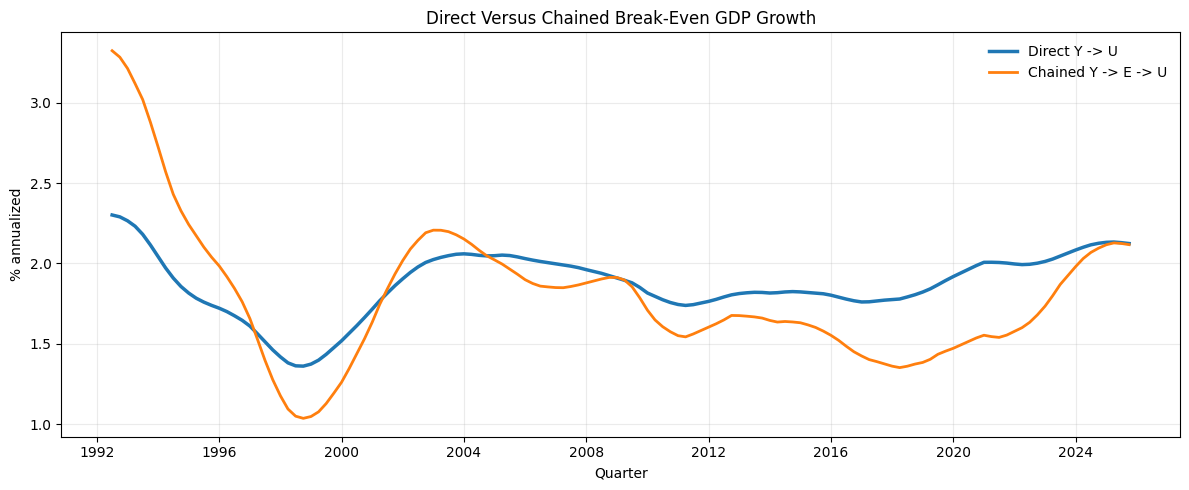

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(compare_df['date'], compare_df['direct_break_even_annualized_pct'], linewidth=2.5, label='Direct Y -> U')
ax.plot(compare_df['date'], compare_df['chained_break_even_annualized_pct'], linewidth=2.0, label='Chained Y -> E -> U')
ax.set_title('Direct Versus Chained Break-Even GDP Growth')
ax.set_ylabel('% annualized')
ax.set_xlabel('Quarter')
ax.grid(alpha=0.25)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## Save Comparison

In [6]:
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
compare_df.to_csv(OUTPUT_PATH, index=False)
OUTPUT_PATH

PosixPath('/Users/christianhepenstrick/codex_projects/swiss-labour-break-even-rates/outputs/compare_chained_and_direct.csv')